# 📊 IMU 数据可视化
这个 Notebook 用来加载并可视化某个 subject 的扰动数据。

In [29]:
import os
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.io import loadmat

def visualize_subject(root="Data", subject="15", pert_index=0, num_imus=5):
    """
    可视化某个 subject 的某次扰动，并展示 DataFrame
    只保留 IMU1–IMU5 的数据 (50 通道)
    """
    subj_folder = os.path.join(root, f"HAB-{subject}", "Processed")
    files = [f for f in os.listdir(subj_folder) if f.endswith(".mat")]
    files.sort()

    if len(files) == 0:
        print("没有找到 .mat 文件")
        return

    # 选第一个 mat 文件
    file = os.path.join(subj_folder, files[0])
    print(f"加载 {file}")

    mat = loadmat(file)
    perturbations = mat['perturbation_data'][0]

    if pert_index >= len(perturbations):
        print(f"这个文件里只有 {len(perturbations)} 个扰动")
        return

    data = perturbations[pert_index]  # shape: [time_steps, signals]
    print("原始数据形状:", data.shape)

    # === 只保留前 50 列 (IMU1–5)，去掉 IMU6 和 IMU7 ===
    data = data[:, :num_imus*10]
    time_steps, signals = data.shape
    print("过滤后的数据形状:", data.shape)

    # ==== DataFrame ====
    columns = []
    for imu_idx in range(num_imus):  # 只保留前 num_imus 个
        cols = [f"IMU{imu_idx+1}_Ax", f"IMU{imu_idx+1}_Ay", f"IMU{imu_idx+1}_Az",
                f"IMU{imu_idx+1}_Gx", f"IMU{imu_idx+1}_Gy", f"IMU{imu_idx+1}_Gz",
                f"IMU{imu_idx+1}_Mx", f"IMU{imu_idx+1}_My", f"IMU{imu_idx+1}_Mz",
                f"IMU{imu_idx+1}_Qw"]
        columns.extend(cols)

    df = pd.DataFrame(data, columns=columns)
    print("\n=== 前 5 行数据 (只保留 IMU1–5) ===")
    print(df.head())

    # ==== 可视化 ====
    fig, axs = plt.subplots(num_imus, 1, figsize=(12, 2*num_imus), sharex=True)

    for imu_idx in range(num_imus):
        start_col = imu_idx * 10
        accel = data[:, start_col:start_col+3]
        gyro  = data[:, start_col+3:start_col+6]

        axs[imu_idx].plot(accel, label=["Ax","Ay","Az"])
        axs[imu_idx].plot(gyro,  label=["Gx","Gy","Gz"], linestyle="--")
        axs[imu_idx].set_ylabel(f"IMU{imu_idx+1}")
        axs[imu_idx].legend(loc="upper right", fontsize=8)

    axs[-1].set_xlabel("Time step")
    plt.suptitle(f"Subject {subject} - Perturbation {pert_index}")
    plt.tight_layout()
    plt.show()




加载 ../IMU_Data/HAB-20/Processed/HS_B_Left_1.mat
原始数据形状: (7041, 70)
过滤后的数据形状: (7041, 50)

=== 前 5 行数据 (只保留 IMU1–5) ===
    IMU1_Ax  IMU1_Ay  IMU1_Az   IMU1_Gx  IMU1_Gy   IMU1_Gz   IMU1_Mx  IMU1_My  \
0 -0.128906    9.875 -0.90625  0.005859      0.0 -0.001953  0.659851 -0.33313   
1 -0.128906    9.875 -0.90625  0.005859      0.0 -0.001953  0.659851 -0.33313   
2 -0.128906    9.875 -0.90625  0.001953      0.0 -0.003906  0.659912 -0.33313   
3 -0.128906    9.875 -0.90625  0.001953      0.0 -0.003906  0.659912 -0.33313   
4 -0.128906    9.875 -0.90625  0.001953      0.0 -0.003906  0.659912 -0.33313   

   IMU1_Mz  IMU1_Qw  ...   IMU5_Ax   IMU5_Ay   IMU5_Az   IMU5_Gx   IMU5_Gy  \
0 -0.30896  0.59845  ...  0.863281  9.523438  1.992188  0.009766 -0.003906   
1 -0.30896  0.59845  ...  0.863281  9.523438  1.992188  0.009766 -0.003906   
2 -0.30896  0.59845  ...  0.863281  9.523438  1.992188  0.009766 -0.003906   
3 -0.30896  0.59845  ...  0.863281  9.523438  1.992188  0.009766 -0.003906   
4 -0.

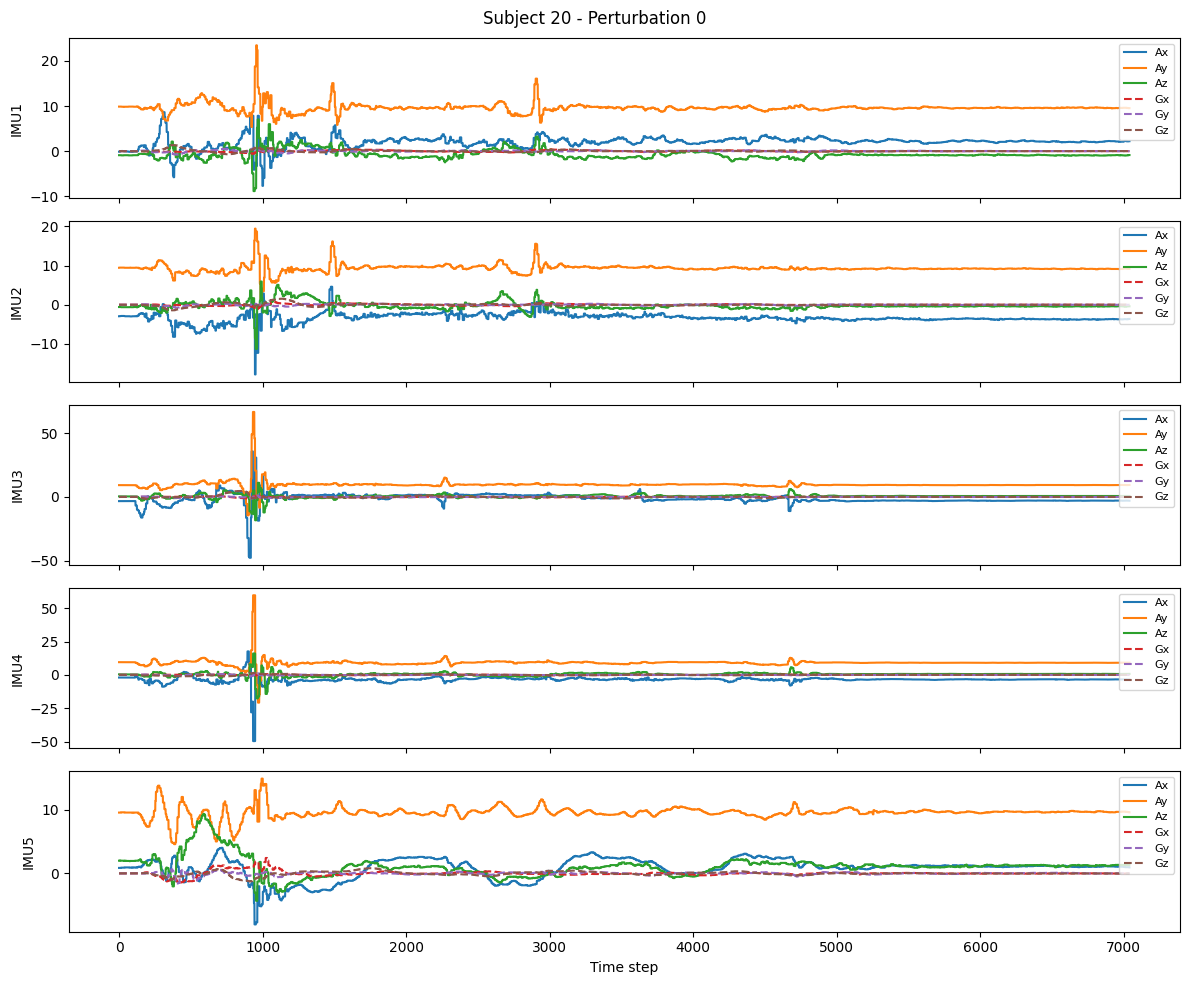

加载 ../IMU_Data/HAB-20/Processed/HS_B_Left_1.mat
原始数据形状: (9744, 70)
过滤后的数据形状: (9744, 50)

=== 前 5 行数据 (只保留 IMU1–5) ===
    IMU1_Ax   IMU1_Ay   IMU1_Az   IMU1_Gx   IMU1_Gy   IMU1_Gz   IMU1_Mx  \
0  2.015625  9.648438 -0.945312  0.007812  0.013672  0.003906  0.626282   
1  2.015625  9.648438 -0.945312  0.007812  0.013672  0.003906  0.626282   
2  2.015625  9.648438 -0.945312  0.007812  0.013672  0.003906  0.626282   
3  2.015625  9.648438 -0.945312  0.007812  0.013672  0.003906  0.626282   
4  2.015625  9.648438 -0.945312  0.007812  0.013672  0.003906  0.626282   

    IMU1_My   IMU1_Mz   IMU1_Qw  ...   IMU5_Ax   IMU5_Ay   IMU5_Az   IMU5_Gx  \
0 -0.388367 -0.224426  0.637573  ...  0.828125  9.710938  1.953125  0.125000   
1 -0.388367 -0.224426  0.637573  ...  0.828125  9.710938  1.953125  0.125000   
2 -0.388367 -0.224426  0.637573  ...  0.828125  9.710938  1.953125  0.125000   
3 -0.388367 -0.224426  0.637573  ...  0.828125  9.710938  1.953125  0.101562   
4 -0.388367 -0.224426  0.637573

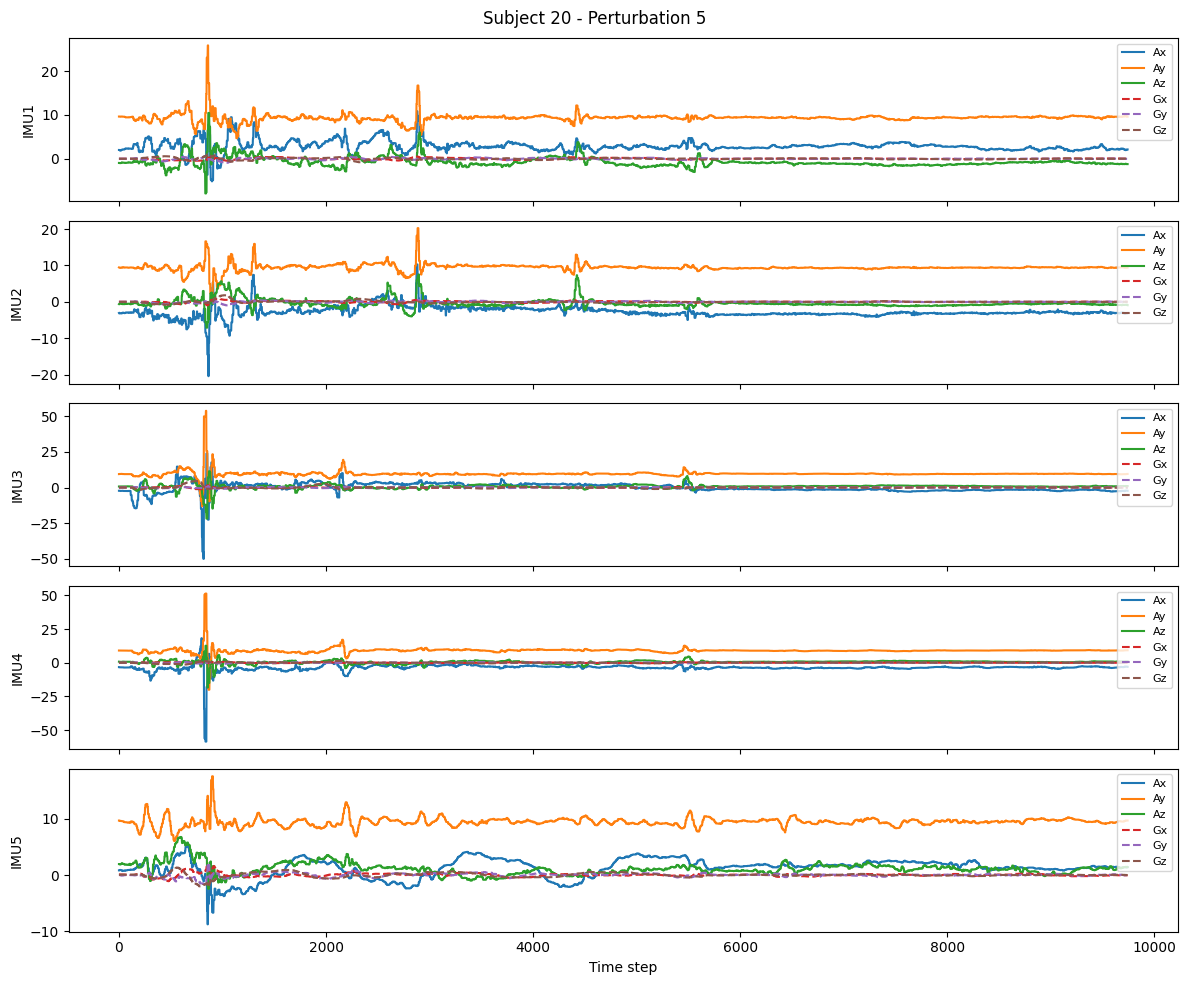

In [26]:

# ✅ 运行这个 cell 测试
visualize_subject(root="../IMU_Data", subject="20", pert_index=0, num_imus=5)
visualize_subject(root="../IMU_Data", subject="20", pert_index=5, num_imus=5)


In [39]:
mat_path = "../IMU_Data/HAB-20/Processed/HS_B_Left_1.mat"
mat_data = sio.loadmat(mat_path)

print("Keys in mat file:", mat_data.keys())

pert_data = mat_data['perturbation_data']
print("perturbation_data type:", type(pert_data))
print("perturbation_data shape:", pert_data.shape)

# 取第一个 perturbation
first_pert = pert_data[0, 0]  # 注意这里可能是结构体或 ndarray
print("First perturbation type:", type(first_pert))

# 如果是结构体，打印字段名
if hasattr(first_pert, "_fieldnames"):
    print("Field names in first perturbation:", first_pert._fieldnames)
    # 取前6个字段名
    print("前6个字段名:", first_pert._fieldnames[:6])

# 如果是 ndarray，打印前6列数值范围
elif isinstance(first_pert, np.ndarray):
    print("Shape of first perturbation data:", first_pert.shape)
    print("前6列前10行:\n", first_pert[:10, :6])
    for i in range(6):
        print(f"Col {i}: min={first_pert[:, i].min()}, max={first_pert[:, i].max()}")

else:
    print("未知数据类型:", type(first_pert))



Keys in mat file: dict_keys(['__header__', '__version__', '__globals__', 'perturbation_data'])
perturbation_data type: <class 'numpy.ndarray'>
perturbation_data shape: (1, 10)
First perturbation type: <class 'numpy.ndarray'>
Shape of first perturbation data: (7041, 70)
前6列前10行:
 [[-1.2890625e-01  9.8750000e+00 -9.0625000e-01  5.8593750e-03
   0.0000000e+00 -1.9531250e-03]
 [-1.2890625e-01  9.8750000e+00 -9.0625000e-01  5.8593750e-03
   0.0000000e+00 -1.9531250e-03]
 [-1.2890625e-01  9.8750000e+00 -9.0625000e-01  1.9531250e-03
   0.0000000e+00 -3.9062500e-03]
 [-1.2890625e-01  9.8750000e+00 -9.0625000e-01  1.9531250e-03
   0.0000000e+00 -3.9062500e-03]
 [-1.2890625e-01  9.8750000e+00 -9.0625000e-01  1.9531250e-03
   0.0000000e+00 -3.9062500e-03]
 [-1.2890625e-01  9.8750000e+00 -9.0625000e-01  1.9531250e-03
   0.0000000e+00 -3.9062500e-03]
 [-1.2890625e-01  9.8750000e+00 -9.0625000e-01  1.9531250e-03
   0.0000000e+00 -3.9062500e-03]
 [-1.1718750e-02  9.8750000e+00 -9.0625000e-01  1.95312